# ResNet50 — Multi-Class Alzheimer's Classification (Scan-Level)

In [1]:
import os
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
# from captum.attr import IntegratedGradients, Saliency

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Loading the Dataset

In [2]:
DATA_ROOT = "/kaggle/input/datasets/malakkhaled202300369/adni-data/adni_nifti_preprocessed"

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")
print(f"Number of classes: {len(CLASS_NAMES)}")

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

all_paths  = []
all_labels = []

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f"\nTotal images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Classes found: ['AD', 'CN', 'MCI']
Number of classes: 3

Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


# Configuration

In [3]:
OUTPUT_DIR = "/kaggle/working/preprocessed_resnet50"
CKPT_DIR   = "/kaggle/working/checkpoints_resnet50"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
TRAIN_RATIO  = 0.80
BATCH_SIZE   = 32
NUM_EPOCHS   = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
LABEL_SMOOTH = 0.1
GRAD_CLIP    = 1.0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Splitting (Train, Validation, and Test)

In [4]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")


Train: 6809 | Val: 851 | Test: 852


In [5]:
# Check for data leakage
train_set = set(train_paths)
val_set   = set(val_paths)
test_set  = set(test_paths)

overlap_train_val  = len(train_set & val_set)
overlap_train_test = len(train_set & test_set)
overlap_val_test   = len(val_set & test_set)

print(f"Train-Val overlap:  {overlap_train_val}")
print(f"Train-Test overlap: {overlap_train_test}")
print(f"Val-Test overlap:   {overlap_val_test}")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print("\u2713 No data leakage")
else:
    print("\u2717 Data leakage detected!")

# Class distribution per split
print("\nClass distribution:")
for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}: {dict(sorted(c.items()))}")

Train-Val overlap:  0
Train-Test overlap: 0
Val-Test overlap:   0
✓ No data leakage

Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


# Saving Tensors

In [6]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base_fname   = os.path.splitext(os.path.basename(path))[0]
        tracking_key = f"{cls_name}_{base_fname}"

        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique_fname = f"{base_fname}_dup{filename_usage[tracking_key]}.pt"
        else:
            filename_usage[tracking_key] = 0
            unique_fname = f"{base_fname}.pt"

        out_path = os.path.join(out_dir, unique_fname)
        img    = Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = transforms.ToTensor()(img)
        tensor = (tensor * 255).byte()
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths,   val_labels,   "val")
save_tensors(test_paths,  test_labels,  "test")

print("All tensors saved.")

Saving test: 100%|██████████| 852/852 [00:06<00:00, 129.95it/s]

All tensors saved.


# Dataset Class

In [7]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self):
        return [s[1] for s in self.samples]

# Load datasets
train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"),   CLASS_NAMES, augment=False)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"),  CLASS_NAMES, augment=False)

print(f"Dataset sizes:")
print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Dataset sizes:
  Train: 6809 | Val: 851 | Test: 852


# Weighted Sampling For Class Imbalance

In [8]:
train_labels_list = train_ds.get_labels()
class_counts      = Counter(train_labels_list)
print(f"Training class distribution: {dict(sorted(class_counts.items()))}")

sample_weights = [1.0 / class_counts[label] for label in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=4, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True
)

Training class distribution: {0: 1147, 1: 1873, 2: 3789}


# Model

In [9]:
def build_resnet50(num_classes):
    """Build ResNet50 for multi-class classification.
    Backbone frozen; custom head: BN -> Linear(2048->512) -> ReLU -> Dropout(0.5) -> Linear(512, num_classes).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  ResNet50: {trainable:,} trainable / {total:,} total params ({trainable/total*100:.1f}%)")
    return model

model = build_resnet50(num_classes=len(CLASS_NAMES)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler    = torch.amp.GradScaler()

print(f"\nModel initialized with {len(CLASS_NAMES)} output classes")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


  ResNet50: 1,054,723 trainable / 24,562,755 total params (4.3%)

Model initialized with 3 output classes


# Training

In [10]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    """Run one epoch of training or validation."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()

            preds = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

In [11]:
ckpt_path = os.path.join(CKPT_DIR, "best_resnet50_multiclass.pt")

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0
patience_ctr = 0

print(f"  TRAINING RESNET50 MULTI-CLASS CLASSIFIER")
print(f"  Classes: {CLASS_NAMES}")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(
        train_loader, model, criterion, optimizer, scaler,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]"
    )
    vl_loss, vl_acc, val_preds, val_lbls = run_epoch(
        val_loader, model, criterion,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]"
    )

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_lbls, val_preds, average=None, zero_division=0
    )

    cur_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | "
          f"val loss={vl_loss:.4f} acc={vl_acc*100:.2f}% | lr={cur_lr:.2e}")
    print(f"  Val per-class F1: {[f'{f:.3f}' for f in f1]}")

    scheduler.step(vl_loss)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
        print(f"  \u2713 Best val_acc={best_val_acc*100:.2f}% \u2014 saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")

  TRAINING RESNET50 MULTI-CLASS CLASSIFIER
  Classes: ['AD', 'CN', 'MCI']


Epoch 01 | train loss=1.0578 acc=50.55% | val loss=1.0244 acc=47.59% | lr=1.00e-03
  Val per-class F1: ['0.411', '0.555', '0.448']
  ✓ Best val_acc=47.59% — saved.


Epoch 02 | train loss=0.9717 acc=56.28% | val loss=0.9562 acc=56.29% | lr=1.00e-03
  Val per-class F1: ['0.445', '0.536', '0.619']
  ✓ Best val_acc=56.29% — saved.


Epoch 03 | train loss=0.9330 acc=58.47% | val loss=0.9641 acc=55.58% | lr=1.00e-03
  Val per-class F1: ['0.463', '0.604', '0.566']


Epoch 04 | train loss=0.8925 acc=62.39% | val loss=0.8785 acc=60.40% | lr=1.00e-03
  Val per-class F1: ['0.490', '0.584', '0.659']
  ✓ Best val_acc=60.40% — saved.


...

Epoch 36 | train loss=0.5879 acc=84.61% | val loss=0.5851 acc=86.13% | lr=2.50e-04
  Val per-class F1: ['0.850', '0.826', '0.883']
  ✓ Best val_acc=86.13% — saved.


Epoch 37 | train loss=0.5878 acc=84.58% | val loss=0.5928 acc=85.78% | lr=2.50e-04
  Val per-class F1: ['0.829', '0.831', '0.881']


Epoch 38 | train loss=0.5789 acc=85.02% | val loss=0.5895 acc=85.19% | lr=2.50e-04
  Val per-class F1: ['0.822', '0.818', '0.879']


Epoch 39 | train loss=0.5778 acc=85.05% | val loss=0.5953 acc=84.84% | lr=2.50e-04
  Val per-class F1: ['0.822', '0.816', '0.875']


Epoch 40 | train loss=0.5790 acc=85.12% | val loss=0.5918 acc=85.19% | lr=1.25e-04
  Val per-class F1: ['0.826', '0.824', '0.876']

Best validation accuracy: 86.13%


# Training Curves

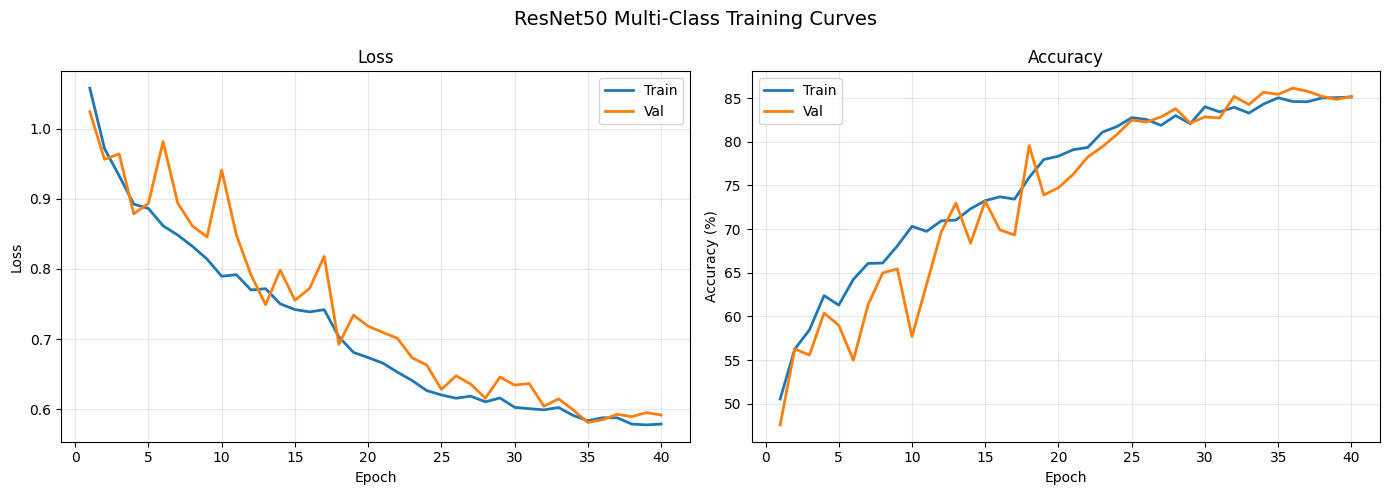

In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 Multi-Class Training Curves', fontsize=14)

axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   linewidth=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "curves_resnet50_multiclass.png"), dpi=150)
plt.show()

# Test Evaluation

In [13]:
print(f"{'='*60}")
print(f"  TEST EVALUATION")
print(f"{'='*60}\n")

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

test_loss, test_acc, test_preds, test_lbls = run_epoch(
    test_loader, model, criterion, desc="Testing"
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%\n")

  TEST EVALUATION



Test Loss:     0.5415
Test Accuracy: 88.26%



# Classification Report

In [14]:
print("Classification Report:")
print("="*60)
print(classification_report(test_lbls, test_preds, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(
    test_lbls, test_preds, average=None, zero_division=0
)

print("\nPer-Class Metrics Summary:")
print("-"*60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:15s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | "
          f"F1: {f1[i]:.4f} | Support: {support[i]}")

macro_f1    = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
print(f"\nMacro F1-Score:    {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

          AD     0.8269    0.8958    0.8600       144
          CN     0.8646    0.8462    0.8553       234
         MCI     0.9101    0.8966    0.9033       474

    accuracy                         0.8826       852
   macro avg     0.8672    0.8795    0.8729       852
weighted avg     0.8835    0.8826    0.8828       852


Per-Class Metrics Summary:
------------------------------------------------------------
AD              | Precision: 0.8269 | Recall: 0.8958 | F1: 0.8600 | Support: 144
CN              | Precision: 0.8646 | Recall: 0.8462 | F1: 0.8553 | Support: 234
MCI             | Precision: 0.9101 | Recall: 0.8966 | F1: 0.9033 | Support: 474

Macro F1-Score:    0.8729
Weighted F1-Score: 0.8828


# Confusion Matrix

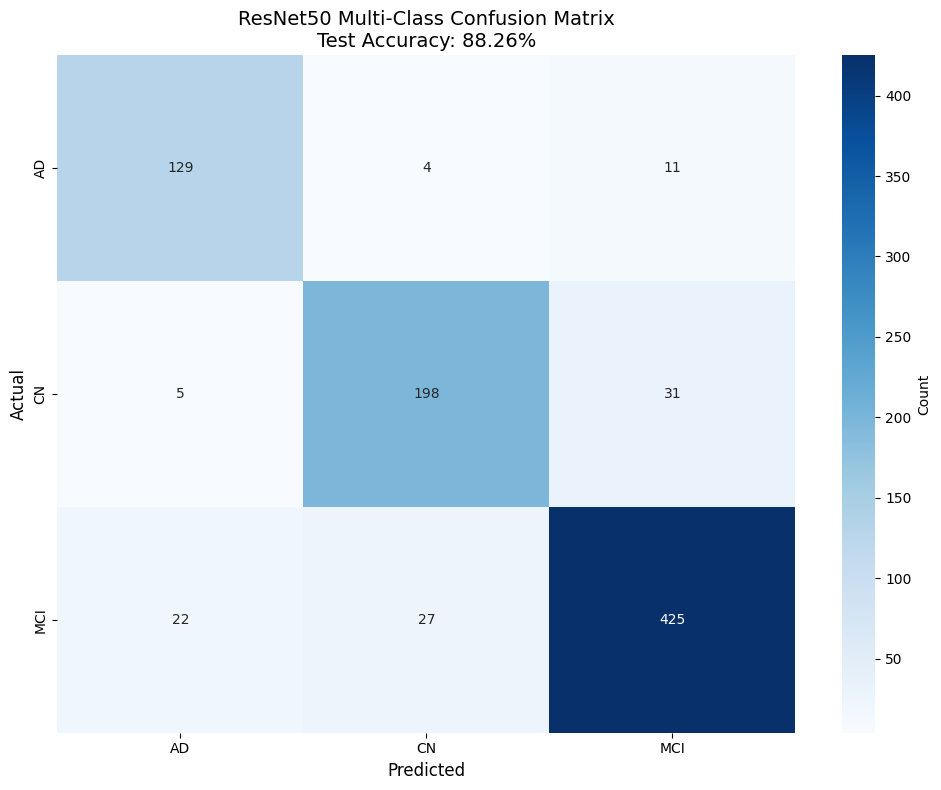

In [15]:
cm = confusion_matrix(test_lbls, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'ResNet50 Multi-Class Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_resnet50_multiclass.png"), dpi=150)
plt.show()

# Saving Results

In [16]:
results = {
    'model': 'ResNet50',
    'num_classes': len(CLASS_NAMES),
    'class_names': CLASS_NAMES,
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_metrics': {
        cls: {
            'precision': float(precision[i]),
            'recall':    float(recall[i]),
            'f1':        float(f1[i]),
            'support':   int(support[i])
        }
        for i, cls in enumerate(CLASS_NAMES)
    },
    'confusion_matrix': cm.tolist(),
    'best_val_acc': float(best_val_acc),
    'hyperparameters': {
        'image_size':    IMAGE_SIZE,
        'batch_size':    BATCH_SIZE,
        'learning_rate': LR,
        'weight_decay':  WEIGHT_DECAY,
        'grad_clip':     GRAD_CLIP,
        'label_smooth':  LABEL_SMOOTH,
        'num_epochs':    len(history['train_loss']),
        'patience':      PATIENCE
    }
}

results_path = os.path.join(CKPT_DIR, "resnet50_multiclass_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\u2713 Results saved to: {results_path}")
print(f"\u2713 Model checkpoint: {ckpt_path}")

print("\n" + "="*60)
print("  TRAINING COMPLETE")
print("="*60)

✓ Results saved to: /kaggle/working/checkpoints_resnet50/resnet50_multiclass_results.json
✓ Model checkpoint: /kaggle/working/checkpoints_resnet50/best_resnet50_multiclass.pt

  TRAINING COMPLETE


In [17]:
import joblib
import os
import shutil
from IPython.display import FileLink, display

save_path = os.path.join(CKPT_DIR, 'ResNet50(ScanLevel)_model_final.pkl')
joblib.dump(model, save_path)

zip_path = "/kaggle/temp/all_project_outputs.zip"
os.makedirs("/kaggle/temp", exist_ok=True)
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working')

final_zip_path = "/kaggle/working/all_project_outputs.zip"
shutil.move(zip_path, final_zip_path)

print("\u2705 Done! Click the link below to download everything:")
display(FileLink("all_project_outputs.zip"))

✅ Done! Click the link below to download everything:


/kaggle/working/all_project_outputs.zip

# XAI

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

def load_sample_image(dataset, idx=0):
    img_tensor, label = dataset[idx]
    img_display = (denormalize(img_tensor).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return img_tensor, img_display, label

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

# Pick one test sample per class
sample_indices = {cls: None for cls in CLASS_NAMES}
for i, (_, lbl) in enumerate(test_ds.samples):
    cls = CLASS_NAMES[lbl]
    if sample_indices[cls] is None:
        sample_indices[cls] = i
    if all(v is not None for v in sample_indices.values()):
        break

print("Sample indices:", sample_indices)

Sample indices: {'AD': 0, 'CN': 144, 'MCI': 378}


# LIME


LIME: AD


  0%|          | 0/1000 [00:00<?, ?it/s]

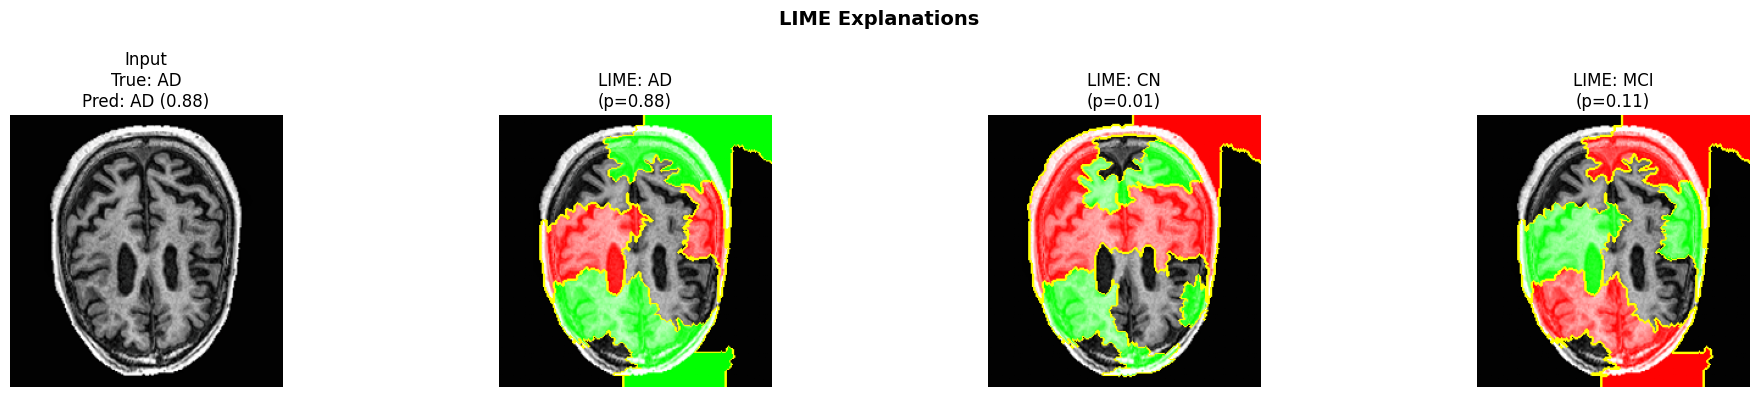


LIME: CN


  0%|          | 0/1000 [00:00<?, ?it/s]

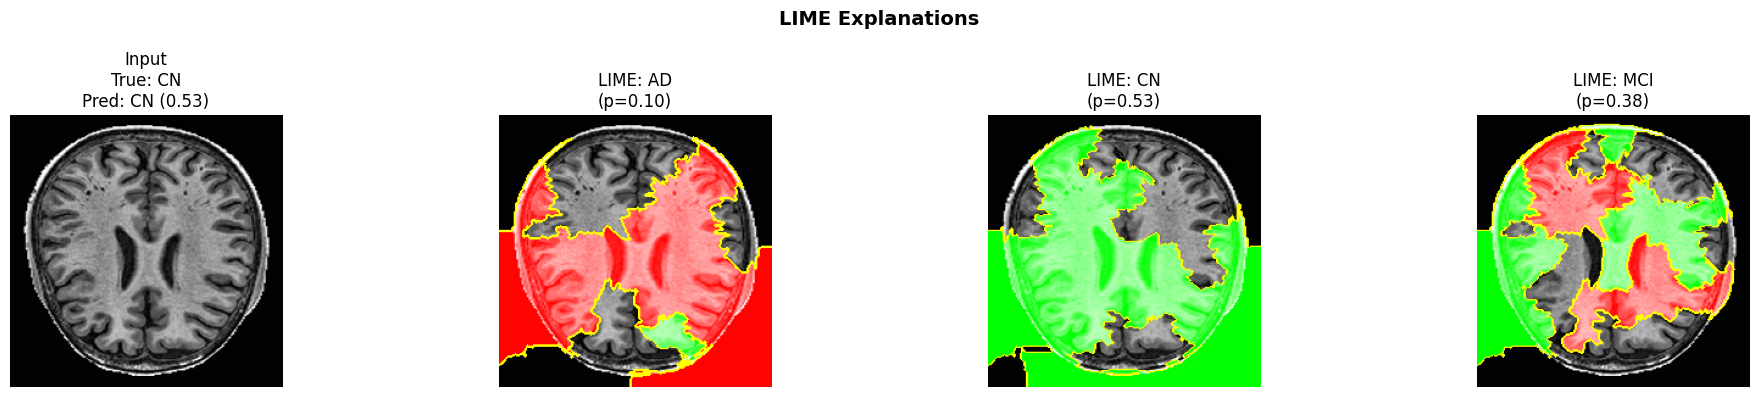


LIME: MCI


  0%|          | 0/1000 [00:00<?, ?it/s]

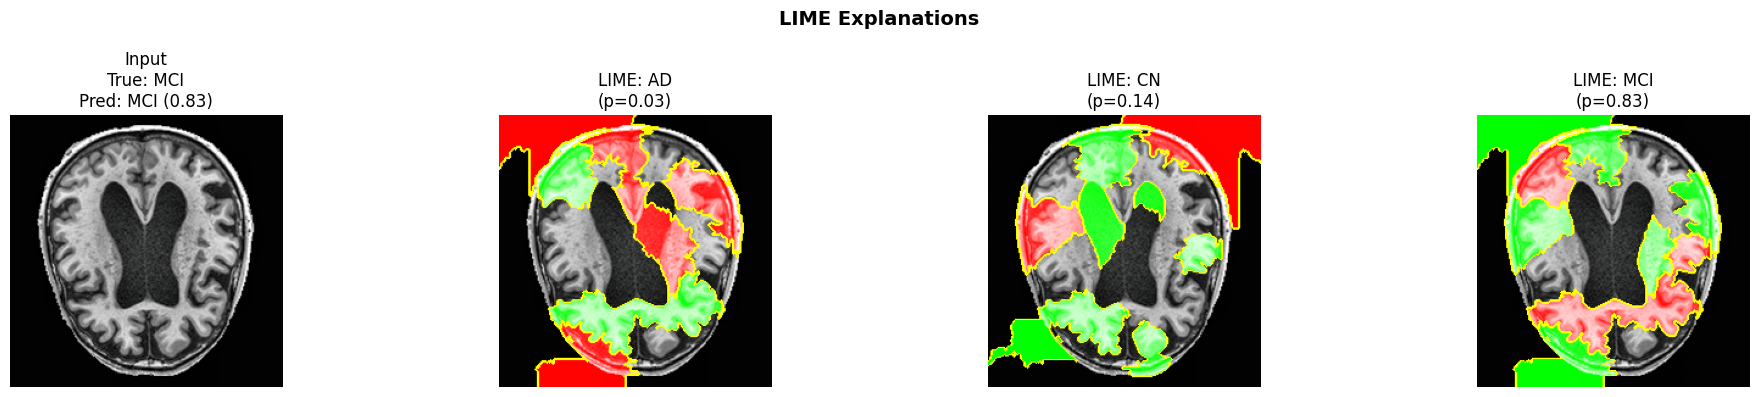

In [19]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_explain(model, dataset, sample_idx, num_samples=1000):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)

    def batch_predict(images):
        model.eval()
        batch = torch.stack([
            normalize(transforms.ToTensor()(img)) for img in images
        ]).to(device)
        with torch.no_grad():
            logits = model(batch)
        return F.softmax(logits, dim=1).cpu().numpy()

    explainer  = lime_image.LimeImageExplainer(random_state=42)
    explanation = explainer.explain_instance(
        img_display, batch_predict,
        top_labels=len(CLASS_NAMES),
        hide_color=0, num_samples=num_samples
    )

    pred_probs = batch_predict([img_display])[0]
    pred_label = pred_probs.argmax()

    fig, axes = plt.subplots(1, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        temp, mask = explanation.get_image_and_mask(
            cls_idx, positive_only=False, num_features=10, hide_rest=False
        )
        axes[i + 1].imshow(mark_boundaries(temp / 255.0, mask))
        axes[i + 1].set_title(f"LIME: {CLASS_NAMES[cls_idx]}\n(p={pred_probs[cls_idx]:.2f})")
        axes[i + 1].axis("off")

    plt.suptitle("LIME Explanations", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return explanation

for cls, idx in sample_indices.items():
    print(f"\nLIME: {cls}")
    lime_explain(model, test_ds, idx, num_samples=1000)

# Grad-CAM


Grad-CAM: AD


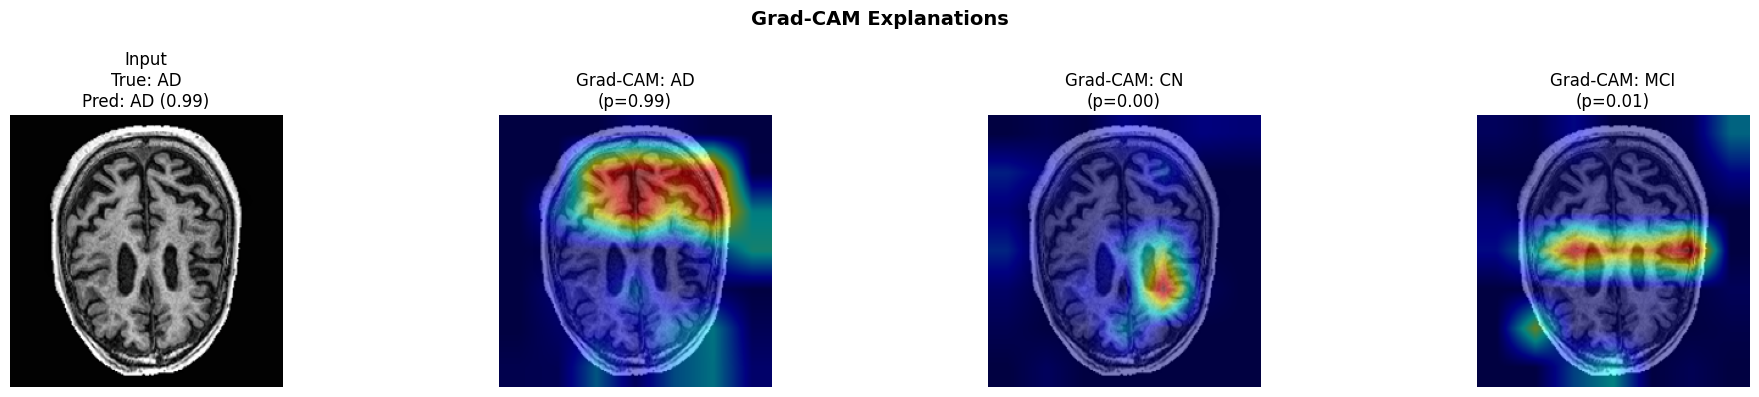


Grad-CAM: CN


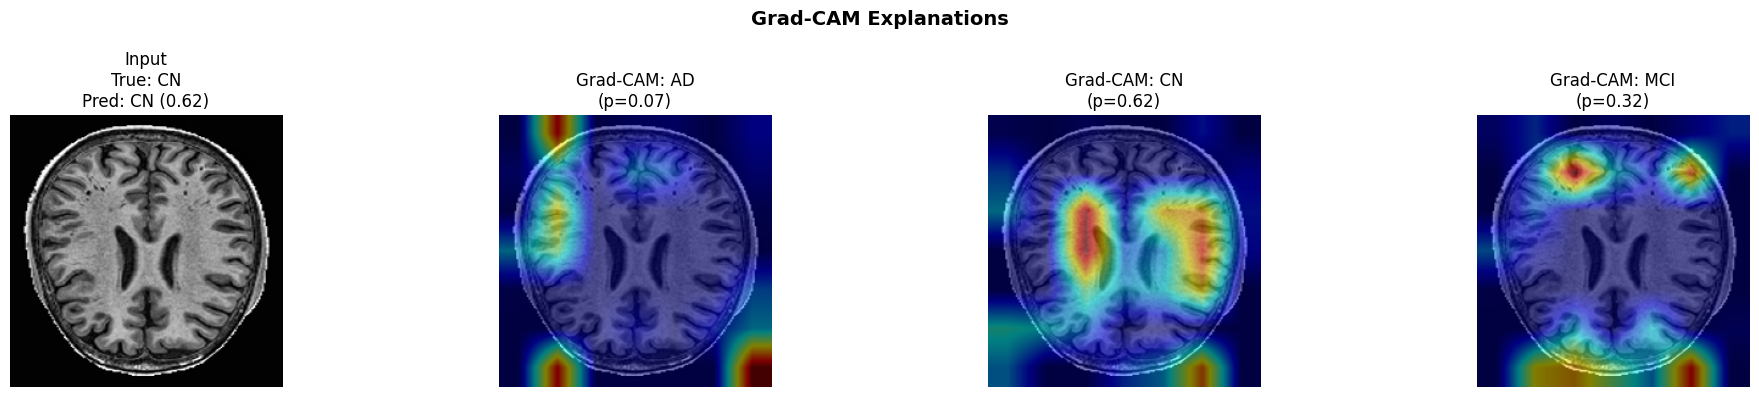


Grad-CAM: MCI


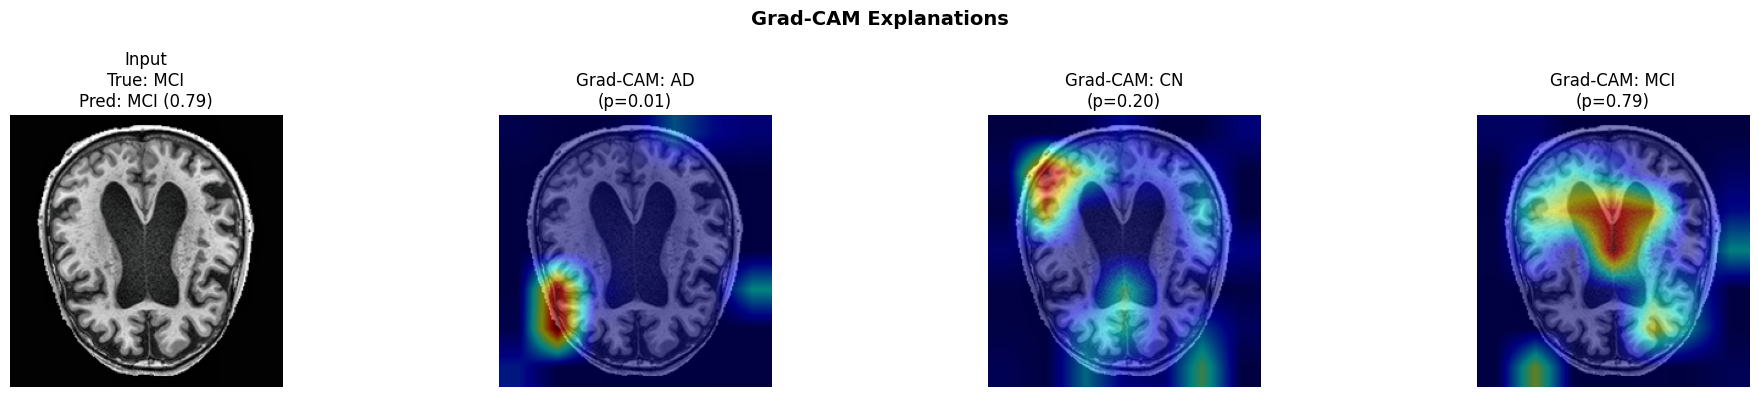

In [20]:
import cv2

class GradCAM:
    """Grad-CAM targeting ResNet50's final residual block (layer4)."""
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        # ResNet50: use the last conv block in layer4
        target_layer = self.model.layer4[-1]

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device).requires_grad_(True)

        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam).squeeze().cpu().numpy()

        cam = cv2.resize(cam, (input_tensor.shape[-1], input_tensor.shape[-2]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class


def gradcam_explain(model, dataset, sample_idx):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)

    with torch.no_grad():
        pred_probs = F.softmax(model(img_tensor.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
    pred_label = pred_probs.argmax()

    gcam = GradCAM(model)

    fig, axes = plt.subplots(1, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        cam, _ = gcam.generate(img_tensor.clone(), target_class=cls_idx)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (0.5 * img_display.astype(float) + 0.5 * heatmap.astype(float)).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"Grad-CAM: {CLASS_NAMES[cls_idx]}\n(p={pred_probs[cls_idx]:.2f})")
        axes[i + 1].axis("off")

    plt.suptitle("Grad-CAM Explanations", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

for cls, idx in sample_indices.items():
    print(f"\nGrad-CAM: {cls}")
    gradcam_explain(model, test_ds, idx)

# Saliency

In [21]:
from captum.attr import Saliency

def saliency_explain(model, dataset, sample_idx):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_probs = F.softmax(model(input_tensor), dim=1).cpu().numpy()[0]
    pred_label = pred_probs.argmax()

    sal = Saliency(model)

    fig, axes = plt.subplots(2, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 8))

    axes[0, 0].imshow(img_display)
    axes[0, 0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0, 0].axis("off")
    axes[1, 0].imshow(img_display)
    axes[1, 0].set_title("Input (ref)")
    axes[1, 0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        attr    = sal.attribute(input_tensor, target=cls_idx, abs=False)
        attr_np = attr.squeeze().cpu().numpy()

        signed = attr_np.mean(axis=0)
        vmax   = np.percentile(np.abs(signed), 99)
        axes[0, i + 1].imshow(signed, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[0, i + 1].set_title(f"Saliency (signed)\n{CLASS_NAMES[cls_idx]} (p={pred_probs[cls_idx]:.2f})")
        axes[0, i + 1].axis("off")

        absolute = np.abs(attr_np).max(axis=0)
        absolute = (absolute - absolute.min()) / (absolute.max() - absolute.min() + 1e-8)
        axes[1, i + 1].imshow(absolute, cmap="hot")
        axes[1, i + 1].set_title(f"Saliency (abs)\n{CLASS_NAMES[cls_idx]}")
        axes[1, i + 1].axis("off")

    plt.suptitle("Saliency Maps (Vanilla Gradient)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

for cls, idx in sample_indices.items():
    print(f"\nSaliency: {cls}")
    saliency_explain(model, test_ds, idx)

ModuleNotFoundError: No module named 'captum'

# Integrated Gradients

In [ ]:
from captum.attr import IntegratedGradients

def ig_explain(model, dataset, sample_idx, n_steps=50):
    img_tensor, img_display, true_label = load_sample_image(dataset, sample_idx)
    input_tensor = img_tensor.unsqueeze(0).to(device)
    baseline     = torch.zeros_like(input_tensor)

    with torch.no_grad():
        pred_probs = F.softmax(model(input_tensor), dim=1).cpu().numpy()[0]
    pred_label = pred_probs.argmax()

    ig = IntegratedGradients(model)

    fig, axes = plt.subplots(2, len(CLASS_NAMES) + 1, figsize=(5 * (len(CLASS_NAMES) + 1), 8))

    axes[0, 0].imshow(img_display)
    axes[0, 0].set_title(f"Input\nTrue: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({pred_probs[pred_label]:.2f})")
    axes[0, 0].axis("off")
    axes[1, 0].imshow(img_display)
    axes[1, 0].set_title("Input (ref)")
    axes[1, 0].axis("off")

    for i, cls_idx in enumerate(range(len(CLASS_NAMES))):
        attr    = ig.attribute(input_tensor, baseline, target=cls_idx, n_steps=n_steps)
        attr_np = attr.squeeze().cpu().numpy()

        signed = attr_np.sum(axis=0)
        vmax   = np.abs(signed).max() + 1e-8
        axes[0, i + 1].imshow(signed, cmap="seismic", vmin=-vmax, vmax=vmax)
        axes[0, i + 1].set_title(f"IG (signed)\n{CLASS_NAMES[cls_idx]} (p={pred_probs[cls_idx]:.2f})")
        axes[0, i + 1].axis("off")

        absolute = np.abs(attr_np).max(axis=0)
        absolute = (absolute - absolute.min()) / (absolute.max() - absolute.min() + 1e-8)
        axes[1, i + 1].imshow(absolute, cmap="hot")
        axes[1, i + 1].set_title(f"IG (abs)\n{CLASS_NAMES[cls_idx]}")
        axes[1, i + 1].axis("off")

    plt.suptitle("Integrated Gradients", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

for cls, idx in sample_indices.items():
    print(f"\nIntegrated Gradients: {cls}")
    ig_explain(model, test_ds, idx, n_steps=50)